# CAISO Load Forecasting — Colab Runner

Runs all forecasting models against any calendar month.  
**GPU runtime recommended** (Runtime → Change runtime type → T4 GPU).

### Setup order
1. Upload `filtered.csv` to Google Drive at `My Drive/load_forecasting/filtered.csv`
2. Run **cell 0** (installs) — takes ~2 min on a fresh runtime
3. Run **cell 1** (clone + mount Drive)
4. Run **cell 2** (config) — sets `PREDICT_MONTH`
5. Run individual model cells in section 3, or the batch cell in section 6

### Papers
| Model | Paper |
|---|---|
| GAM | Fan & Hyndman (2012) — [doi:10.1109/TPWRS.2011.2162082](https://doi.org/10.1109/TPWRS.2011.2162082) |
| TFT | Giacomazzi et al. (2023) — [arXiv:2305.10559](https://arxiv.org/abs/2305.10559) |
| ST-CALNet | Cavus & Allahham (2025) — [doi:10.3390/electronics14132514](https://doi.org/10.3390/electronics14132514) |
| BiLSTM / LSTM / Transformer | Dong et al. (2025) survey — [arXiv:2408.16202](https://arxiv.org/abs/2408.16202) |
| LightGBM, XGBoost, RF | Nti et al. (2020) review — [doi:10.1186/s43067-020-00021-8](https://doi.org/10.1186/s43067-020-00021-8) |

## 0. Install dependencies

In [2]:
import subprocess, sys

pkgs = ['pygam', 'prophet', 'lightgbm', 'xgboost', 'pytorch-forecasting', 'lightning']
for pkg in pkgs:
    r = subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg],
                       capture_output=True, text=True)
    if r.returncode != 0:
        print(f'[WARN] {pkg} install failed:\n{r.stderr[:300]}')
    else:
        print(f'  OK: {pkg}')

print('\nVerifying imports...')
checks = {
    'pygam':   'from pygam import LinearGAM',
    'prophet': 'from prophet import Prophet',
    'lightgbm':'import lightgbm',
    'xgboost': 'import xgboost',
    'torch':   'import torch',
    'pytorch_forecasting': 'import pytorch_forecasting',
}
for name, stmt in checks.items():
    try:
        exec(stmt)
        print(f'  OK: {name}')
    except ImportError as e:
        print(f'  MISSING: {name} — {e}')

  OK: pygam
  OK: prophet
  OK: lightgbm
  OK: xgboost
  OK: pytorch-forecasting
  OK: lightning

Verifying imports...
  OK: pygam
  OK: prophet
  OK: lightgbm
  OK: xgboost
  OK: torch
  OK: pytorch_forecasting


## 1. Clone repo and mount Google Drive

In [3]:
import os, subprocess, sys

REPO_URL = 'https://github.com/Chahnwoo/Load-Forecasting.git'
REPO_DIR = '/content/Load-Forecasting'

if not os.path.exists(REPO_DIR):
    subprocess.run(['git', 'clone', REPO_URL, REPO_DIR], check=True)
else:
    subprocess.run(['git', '-C', REPO_DIR, 'pull'], check=True)

os.chdir(REPO_DIR)
sys.path.insert(0, REPO_DIR)
print(f'Repo ready. cwd = {os.getcwd()}')

Repo ready. cwd = /content/Load-Forecasting


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os
import shutil

# 1. Define your paths
DRIVE_CSV = '/content/Load-Forecasting/data/processed/filtered.csv'
DESTINATION_DIR = 'data/processed'
DESTINATION_FILE = f'{DESTINATION_DIR}/filtered.csv'

# Convert the relative destination path to an absolute (full) path
# so we can compare it directly to our source path.
abs_destination = os.path.abspath(DESTINATION_FILE)

# 2. Check if the source file exists
if not os.path.exists(DRIVE_CSV):
    print(f"Error: Could not find the file at '{DRIVE_CSV}'.")

# 3. Check if the source and destination are the exact same place
elif DRIVE_CSV == abs_destination:
    print(f"The file is already exactly where it needs to be!")
    file_size_mb = os.path.getsize(abs_destination) / 1e6
    print(f'Data ready: {file_size_mb:.0f} MB')

# 4. If it exists and needs to be moved, copy it!
else:
    os.makedirs(DESTINATION_DIR, exist_ok=True)

    # Use Python's built-in copy function instead of terminal commands
    shutil.copy(DRIVE_CSV, DESTINATION_FILE)

    file_size_mb = os.path.getsize(DESTINATION_FILE) / 1e6
    print(f'Data copied and ready: {file_size_mb:.0f} MB')

The file is already exactly where it needs to be!
Data ready: 66 MB


## 2. Configuration
Set the month to forecast. All model cells use these variables.

In [6]:
import os, sys, subprocess

# ── Change this to any YYYY-MM you want to forecast ──
PREDICT_MONTH = '2025-01'

# Regions to train/evaluate on.
# Excluded: caiso (system total = sum of sub-regions),
#           vea (mean 78 MW, hits 0 MW → breaks MAPE),
#           mwd (only exists from Jan 2026, hits 0 MW)
REGIONS = 'pge,sce,sdge'

CSV_PATH    = 'data/processed/filtered.csv'
SCRIPT_PATH = 'src/modeling/train_forecaster.py'
OUTPUT_DIR  = 'outputs/model_runs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

PYTHON = sys.executable

def run_model(model_name, extra_args=''):
    pred_out    = f'{OUTPUT_DIR}/{model_name}_{PREDICT_MONTH}_predictions.csv'
    metrics_out = f'{OUTPUT_DIR}/{model_name}_{PREDICT_MONTH}_metrics.csv'
    cmd = (
        f'{PYTHON} {SCRIPT_PATH} {CSV_PATH}'
        f' --model {model_name}'
        f' --predict_month {PREDICT_MONTH}'
        f' --regions {REGIONS}'
        f' --output_predictions {pred_out}'
        f' --output_metrics {metrics_out}'
        + (f' {extra_args}' if extra_args else '')
    )
    print(f'\n{"="*60}')
    print(f'Running {model_name} for {PREDICT_MONTH}  [regions: {REGIONS}]')
    print(f'{"="*60}')
    sys.stdout.flush()

    proc = subprocess.Popen(
        cmd, shell=True,
        stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
        text=True, bufsize=1
    )
    for line in proc.stdout:
        print(line, end='', flush=True)
    proc.wait()

    if proc.returncode != 0:
        print(f'\n[ERROR] {model_name} exited with code {proc.returncode}')
    else:
        print(f'\n[OK] {model_name} complete.')
    return pred_out, metrics_out

print(f'Config ready.')
print(f'  Month:   {PREDICT_MONTH}')
print(f'  Regions: {REGIONS}')
print(f'  Python:  {PYTHON}')
print(f'  Data:    {os.path.abspath(CSV_PATH)}')

Config ready.
  Month:   2025-01
  Regions: pge,sce,sdge
  Python:  /usr/bin/python3
  Data:    /content/Load-Forecasting/data/processed/filtered.csv


## 3. Models
Each cell below runs one model independently.  
Predictions and metrics are saved to `outputs/model_runs/`.

### 3a. GAM — Semi-parametric additive model
Fan & Hyndman (2012). Best MAPE in our benchmark (~7.9% avg across 2025).  
Uses spline terms for temperature, radiation, lagged load; cyclic splines for hour and day-of-year.

In [6]:
gam_pred, gam_metrics = run_model('gam', '--gam_n_splines 25 --gam_lam 0.6')


Running gam for 2025-01  [regions: pge,sce,sdge]

Forecasting pipeline:  29%|██▊       | 2/7 [00:01<00:03,  1.51step/s]/usr/local/lib/python3.12/dist-packages/pygam/utils.py:79: UserWarning: Could not import Scikit-Sparse or Suite-Sparse.
This will slow down optimization for models with monotonicity/convexity penalties and many splines.
See installation instructions for installing Scikit-Sparse and Suite-Sparse via Conda.
  warnings.warn(msg)

Forecasting pipeline: 100%|██████████| 7/7 [00:13<00:00,  1.96s/step]

[INFO] Reading CSV...

[INFO] Region filter: ['pge', 'sce', 'sdge'] (165,477 rows kept)

[INFO] Preparing train/validation split from predict_month...
[INFO] predict_month           : 2025-01
[INFO] training window end     : 2024-12-31 23:59:59
[INFO] validation window start : 2025-01-01 00:00:00
[INFO] validation window end   : 2025-01-31 23:59:59
[INFO] TRAIN: dropped 0 rows (missing load_mw=0, missing load_previous_week=0).
[INFO] VALID: dropped 0 rows (missing load_mw=0, 

### 3b. XGBoost
Gradient-boosted trees. Second-best in our benchmark.

In [7]:
xgb_pred, xgb_metrics = run_model('xgboost')


Running xgboost for 2025-01  [regions: pge,sce,sdge]

Forecasting pipeline: 100%|██████████| 7/7 [00:08<00:00,  1.26s/step]

[INFO] Reading CSV...

[INFO] Region filter: ['pge', 'sce', 'sdge'] (165,477 rows kept)

[INFO] Preparing train/validation split from predict_month...
[INFO] predict_month           : 2025-01
[INFO] training window end     : 2024-12-31 23:59:59
[INFO] validation window start : 2025-01-01 00:00:00
[INFO] validation window end   : 2025-01-31 23:59:59
[INFO] TRAIN: dropped 0 rows (missing load_mw=0, missing load_previous_week=0).
[INFO] VALID: dropped 0 rows (missing load_mw=0, missing load_previous_week=0).

[INFO] Building shared feature pipeline...

[INFO] Training model: xgboost

[INFO] Computing validation metrics...

VALIDATION METRICS
RMSE           : 500.5281
MAE            : 295.8504
MAPE           : 3.8857%
BIAS           : -150.9749
MEAN_ACTUAL    : 7,951.4975
MEAN_FORECAST  : 7,800.5225
MSE            : 250,528.3805

[INFO] Saving predictions and metric

### 3c. LightGBM
Faster gradient boosting with leaf-wise tree growth.

In [8]:
lgbm_pred, lgbm_metrics = run_model(
    'lightgbm',
    '--lgbm_n_estimators 300 --lgbm_learning_rate 0.05 --lgbm_num_leaves 31'
)


Running lightgbm for 2025-01  [regions: pge,sce,sdge]

Forecasting pipeline:  43%|████▎     | 3/7 [00:02<00:02,  1.37step/s]/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(

Forecasting pipeline: 100%|██████████| 7/7 [00:06<00:00,  1.14step/s]

[INFO] Reading CSV...

[INFO] Region filter: ['pge', 'sce', 'sdge'] (165,477 rows kept)

[INFO] Preparing train/validation split from predict_month...
[INFO] predict_month           : 2025-01
[INFO] training window end     : 2024-12-31 23:59:59
[INFO] validation window start : 2025-01-01 00:00:00
[INFO] validation window end   : 2025-01-31 23:59:59
[INFO] TRAIN: dropped 0 rows (missing load_mw=0, missing load_previous_week=0).
[INFO] VALID: dropped 0 rows (missing load_mw=0, missing load_previous_week=0).

[INFO] Building shared feature pipeline...

[INFO] Training model: lightgbm

[INFO] Computing validati

### 3d. LightGBM + XGBoost Ensemble
Weighted average of both boosters. Reduces variance compared to either alone.

In [9]:
ens_pred, ens_metrics = run_model(
    'lgbm_xgb',
    '--lgbm_n_estimators 300 --lgbm_learning_rate 0.05 --lgbm_num_leaves 31 '
    '--xgb_n_estimators 300 --xgb_learning_rate 0.05 --ensemble_weight 0.5'
)


Running lgbm_xgb for 2025-01  [regions: pge,sce,sdge]

Forecasting pipeline:  43%|████▎     | 3/7 [00:02<00:03,  1.12step/s]/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(

Forecasting pipeline: 100%|██████████| 7/7 [00:14<00:00,  2.14s/step]

[INFO] Reading CSV...

[INFO] Region filter: ['pge', 'sce', 'sdge'] (165,477 rows kept)

[INFO] Preparing train/validation split from predict_month...
[INFO] predict_month           : 2025-01
[INFO] training window end     : 2024-12-31 23:59:59
[INFO] validation window start : 2025-01-01 00:00:00
[INFO] validation window end   : 2025-01-31 23:59:59
[INFO] TRAIN: dropped 0 rows (missing load_mw=0, missing load_previous_week=0).
[INFO] VALID: dropped 0 rows (missing load_mw=0, missing load_previous_week=0).

[INFO] Building shared feature pipeline...

[INFO] Training model: lgbm_xgb

[INFO] Computing validati

### 3e. Random Forest
Bagged trees — good interpretable baseline.

In [10]:
rf_pred, rf_metrics = run_model('random_forest', '--rf_n_estimators 300')


Running random_forest for 2025-01  [regions: pge,sce,sdge]

Forecasting pipeline: 100%|██████████| 7/7 [13:23<00:00, 114.74s/step]

[INFO] Reading CSV...

[INFO] Region filter: ['pge', 'sce', 'sdge'] (165,477 rows kept)

[INFO] Preparing train/validation split from predict_month...
[INFO] predict_month           : 2025-01
[INFO] training window end     : 2024-12-31 23:59:59
[INFO] validation window start : 2025-01-01 00:00:00
[INFO] validation window end   : 2025-01-31 23:59:59
[INFO] TRAIN: dropped 0 rows (missing load_mw=0, missing load_previous_week=0).
[INFO] VALID: dropped 0 rows (missing load_mw=0, missing load_previous_week=0).

[INFO] Building shared feature pipeline...

[INFO] Training model: random_forest

[INFO] Computing validation metrics...

VALIDATION METRICS
RMSE           : 498.0293
MAE            : 299.6258
MAPE           : 3.9170%
BIAS           : -106.8350
MEAN_ACTUAL    : 7,951.4975
MEAN_FORECAST  : 7,844.6625
MSE            : 248,033.1632

[INFO] Saving predictio

### 3f. Prophet
Facebook Prophet: trend + yearly/weekly/daily seasonality + weather regressors.  
Fits one model per region. ~5–10 min.

In [11]:
prophet_pred, prophet_metrics = run_model(
    'prophet',
    '--prophet_changepoint_prior_scale 0.05 --prophet_seasonality_prior_scale 10.0'
)


Running prophet for 2025-01  [regions: pge,sce,sdge]

Forecasting pipeline:  29%|██▊       | 2/7 [00:01<00:03,  1.28step/s]21:51:17 - cmdstanpy - INFO - Chain [1] start processing
21:52:11 - cmdstanpy - INFO - Chain [1] done processing
21:52:16 - cmdstanpy - INFO - Chain [1] start processing
21:52:55 - cmdstanpy - INFO - Chain [1] done processing
21:52:59 - cmdstanpy - INFO - Chain [1] start processing
21:53:39 - cmdstanpy - INFO - Chain [1] done processing

Forecasting pipeline: 100%|██████████| 7/7 [02:30<00:00, 21.53s/step]

[INFO] Reading CSV...

[INFO] Region filter: ['pge', 'sce', 'sdge'] (165,477 rows kept)

[INFO] Preparing train/validation split from predict_month...
[INFO] predict_month           : 2025-01
[INFO] training window end     : 2024-12-31 23:59:59
[INFO] validation window start : 2025-01-01 00:00:00
[INFO] validation window end   : 2025-01-31 23:59:59
[INFO] TRAIN: dropped 0 rows (missing load_mw=0, missing load_previous_week=0).
[INFO] VALID: dropped 0 rows (miss

### 3g. LSTM
Vanilla unidirectional LSTM over a 24-hour lookback window. ~10 min on T4.

In [12]:
lstm_pred, lstm_metrics = run_model(
    'lstm',
    '--lookback 24 --epochs 10 --batch_size 128 --lr 0.001 '
    '--hidden_dim 64 --num_layers 2 --dropout 0.1'
)


Running lstm for 2025-01  [regions: pge,sce,sdge]

Forecasting pipeline:  43%|████▎     | 3/7 [00:03<00:04,  1.04s/step]
[INFO] Reading CSV...

[INFO] Region filter: ['pge', 'sce', 'sdge'] (165,477 rows kept)

[INFO] Preparing train/validation split from predict_month...
[INFO] predict_month           : 2025-01
[INFO] training window end     : 2024-12-31 23:59:59
[INFO] validation window start : 2025-01-01 00:00:00
[INFO] validation window end   : 2025-01-31 23:59:59
[INFO] TRAIN: dropped 0 rows (missing load_mw=0, missing load_previous_week=0).
[INFO] VALID: dropped 0 rows (missing load_mw=0, missing load_previous_week=0).

[INFO] Building shared feature pipeline...

[INFO] Training model: lstm


LSTM training:   0%|          | 0/10 [00:00<?, ?it/s]

LSTM training:   0%|          | 0/10 [00:05<?, ?it/s, train_mse_loss=0.030511]

LSTM training:  10%|█         | 1/10 [00:05<00:45,  5.05s/it, train_mse_loss=0.030511]

LSTM training:  10%|█         | 1/10 [00:10<00:45,  5.05s/it, train_m

### 3h. BiLSTM — Bidirectional LSTM
Reads the sequence in both directions; head takes `hidden_dim * 2` input.

In [13]:
bilstm_pred, bilstm_metrics = run_model(
    'bilstm',
    '--lookback 24 --epochs 10 --batch_size 128 --lr 0.001 '
    '--hidden_dim 64 --num_layers 2 --dropout 0.1'
)


Running bilstm for 2025-01  [regions: pge,sce,sdge]

Forecasting pipeline:  43%|████▎     | 3/7 [00:02<00:03,  1.33step/s]
[INFO] Reading CSV...

[INFO] Region filter: ['pge', 'sce', 'sdge'] (165,477 rows kept)

[INFO] Preparing train/validation split from predict_month...
[INFO] predict_month           : 2025-01
[INFO] training window end     : 2024-12-31 23:59:59
[INFO] validation window start : 2025-01-01 00:00:00
[INFO] validation window end   : 2025-01-31 23:59:59
[INFO] TRAIN: dropped 0 rows (missing load_mw=0, missing load_previous_week=0).
[INFO] VALID: dropped 0 rows (missing load_mw=0, missing load_previous_week=0).

[INFO] Building shared feature pipeline...

[INFO] Training model: bilstm


BILSTM training:   0%|          | 0/10 [00:00<?, ?it/s]

BILSTM training:   0%|          | 0/10 [00:05<?, ?it/s, train_mse_loss=0.028060]

BILSTM training:  10%|█         | 1/10 [00:05<00:53,  5.94s/it, train_mse_loss=0.028060]

BILSTM training:  10%|█         | 1/10 [00:11<00:53,  5.94s

### 3i. Transformer
Multi-head self-attention encoder over the lookback window.

In [14]:
tfm_pred, tfm_metrics = run_model(
    'transformer',
    '--lookback 24 --epochs 10 --batch_size 128 --lr 0.001 '
    '--d_model 64 --nhead 4 --num_layers 2 --dim_feedforward 128 --dropout 0.1'
)


Running transformer for 2025-01  [regions: pge,sce,sdge]

Forecasting pipeline:  43%|████▎     | 3/7 [00:02<00:03,  1.32step/s]
[INFO] Reading CSV...

[INFO] Region filter: ['pge', 'sce', 'sdge'] (165,477 rows kept)

[INFO] Preparing train/validation split from predict_month...
[INFO] predict_month           : 2025-01
[INFO] training window end     : 2024-12-31 23:59:59
[INFO] validation window start : 2025-01-01 00:00:00
[INFO] validation window end   : 2025-01-31 23:59:59
[INFO] TRAIN: dropped 0 rows (missing load_mw=0, missing load_previous_week=0).
[INFO] VALID: dropped 0 rows (missing load_mw=0, missing load_previous_week=0).

[INFO] Building shared feature pipeline...

[INFO] Training model: transformer


TRANSFORMER training:   0%|          | 0/10 [00:00<?, ?it/s]

TRANSFORMER training:   0%|          | 0/10 [00:09<?, ?it/s, train_mse_loss=0.022490]

TRANSFORMER training:  10%|█         | 1/10 [00:09<01:22,  9.18s/it, train_mse_loss=0.022490]

TRANSFORMER training:  10%|█      

### 3j. ST-CALNet — Spatio-Temporal CNN-Attention-LSTM
Cavus & Allahham (2025): Conv1d → LSTM → scaled-dot-product attention → LayerNorm → LSTM → Dense.  
~30–60 min on T4.

In [15]:
stcalnet_pred, stcalnet_metrics = run_model(
    'stcalnet',
    '--lookback 24 --epochs 10 --batch_size 128 --lr 0.001 '
    '--hidden_dim 64 --num_layers 2 --cnn_channels 64 --dropout 0.1'
)


Running stcalnet for 2025-01  [regions: pge,sce,sdge]

Forecasting pipeline:  43%|████▎     | 3/7 [00:02<00:03,  1.31step/s]
[INFO] Reading CSV...

[INFO] Region filter: ['pge', 'sce', 'sdge'] (165,477 rows kept)

[INFO] Preparing train/validation split from predict_month...
[INFO] predict_month           : 2025-01
[INFO] training window end     : 2024-12-31 23:59:59
[INFO] validation window start : 2025-01-01 00:00:00
[INFO] validation window end   : 2025-01-31 23:59:59
[INFO] TRAIN: dropped 0 rows (missing load_mw=0, missing load_previous_week=0).
[INFO] VALID: dropped 0 rows (missing load_mw=0, missing load_previous_week=0).

[INFO] Building shared feature pipeline...

[INFO] Training model: stcalnet


STCALNET training:   0%|          | 0/10 [00:00<?, ?it/s]

STCALNET training:   0%|          | 0/10 [00:07<?, ?it/s, train_mse_loss=0.020324]

STCALNET training:  10%|█         | 1/10 [00:07<01:10,  7.82s/it, train_mse_loss=0.020324]

STCALNET training:  10%|█         | 1/10 [00:14<0

### 3k. Temporal Fusion Transformer (TFT)
Giacomazzi et al. (2023). LSTM encoder + variable-selection + multi-head attention.  
Target MAPE: ~2.43%. Requires `pytorch-forecasting`. ~15–30 min on T4.

In [18]:
import os, sys
import numpy as np
import pandas as pd

try:
    from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
    from pytorch_forecasting.data import GroupNormalizer
    from pytorch_forecasting.metrics import MAPE as TFT_MAPE
    import lightning as L
    _tft_ok = True
except ImportError as e:
    _tft_ok = False
    print(f'[SKIP] pytorch-forecasting not available: {e}')
    print('Run cell 0 first to install all dependencies.')

if _tft_ok:
    from src.modeling.train_forecaster import (
        set_seed, build_features, parse_predict_month, compute_metrics
    )

    set_seed(42)

    df_raw = pd.read_csv(CSV_PATH)
    month_start, next_month_start, _ = parse_predict_month(PREDICT_MONTH)

    df_raw['time_utc'] = pd.to_datetime(df_raw['time_utc'])

    train_df = build_features(df_raw[df_raw['time_utc'] < month_start].copy())
    valid_df = build_features(
        df_raw[
            (df_raw['time_utc'] >= month_start) &
            (df_raw['time_utc'] < next_month_start)
        ].copy()
    )

    train_df = train_df.dropna(subset=['load_mw', 'load_previous_week']).copy()
    valid_df = valid_df.dropna(subset=['load_mw', 'load_previous_week']).copy()

    LOOKBACK = 24

    TFT_KNOWN = [
        c for c in [
            'temperature_2m',
            'apparent_temperature',
            'relative_humidity_2m',
            'precipitation',
            'cloud_cover',
            'wind_speed_10m',
            'shortwave_radiation',
            'cdd_65f',
            'hdd_65f',
            'hour',
            'day_of_week',
            'month',
            'is_weekend',
            'is_holiday',
        ]
        if c in train_df.columns
    ]

    def make_tft_df(df):
        out = df.sort_values(['region', 'time_utc']).copy()
        out['region'] = out['region'].astype(str)
        out['load_mw'] = out['load_mw'].astype(float)
        return out

    train_df = make_tft_df(train_df)
    valid_df = make_tft_df(valid_df)

    combined = pd.concat([train_df, valid_df], ignore_index=True)
    combined = combined.sort_values(['region', 'time_utc']).reset_index(drop=True)
    combined['time_idx'] = combined.groupby('region').cumcount()

    first_valid_time_idx = (
        combined[combined['time_utc'] >= month_start]
        .groupby('region')['time_idx']
        .min()
        .min()
    )

    train_tft = combined[combined['time_utc'] < month_start].copy()

    ds_train = TimeSeriesDataSet(
        train_tft,
        time_idx='time_idx',
        target='load_mw',
        group_ids=['region'],
        min_encoder_length=LOOKBACK,
        max_encoder_length=LOOKBACK,
        min_prediction_length=1,
        max_prediction_length=1,
        static_categoricals=['region'],
        time_varying_known_reals=TFT_KNOWN,
        time_varying_unknown_reals=['load_mw'],
        target_normalizer=GroupNormalizer(groups=['region'], transformation='softplus'),
        add_relative_time_idx=True,
        add_target_scales=True,
        add_encoder_length=True,
    )

    ds_valid = TimeSeriesDataSet.from_dataset(
        ds_train,
        combined,
        min_prediction_idx=int(first_valid_time_idx),
        stop_randomization=True,
        predict=False,
    )

    train_loader = ds_train.to_dataloader(train=True, batch_size=128, num_workers=2)
    valid_loader = ds_valid.to_dataloader(train=False, batch_size=128, num_workers=2)

    tft_model = TemporalFusionTransformer.from_dataset(
        ds_train,
        learning_rate=1e-3,
        hidden_size=64,
        attention_head_size=4,
        dropout=0.1,
        hidden_continuous_size=32,
        loss=TFT_MAPE(),
        log_interval=50,
        reduce_on_plateau_patience=3,
    )

    print(f'TFT params: {sum(p.numel() for p in tft_model.parameters()):,}')

    trainer = L.Trainer(
        max_epochs=10,
        accelerator='auto',
        enable_progress_bar=True,
        gradient_clip_val=0.1,
        logger=False,
        enable_checkpointing=False,
    )

    trainer.fit(
        tft_model,
        train_dataloaders=train_loader,
        val_dataloaders=valid_loader,
    )

    pred_result = tft_model.predict(
        valid_loader,
        return_index=True,
        return_x=False,
    )

    if hasattr(pred_result, 'output'):
        tft_preds = pred_result.output.detach().cpu().numpy().flatten()
        pred_index = pred_result.index.copy()
    else:
        tft_preds, pred_index = pred_result
        tft_preds = tft_preds.detach().cpu().numpy().flatten()

    pred_index = pred_index.reset_index(drop=True)

    scored = pred_index.copy()
    scored['predicted_load_mw'] = tft_preds[:len(scored)]

    scored = scored.merge(
        combined[['region', 'time_idx', 'time_key', 'time_utc', 'load_mw']],
        on=['region', 'time_idx'],
        how='left',
    )

    scored = scored[
        (scored['time_utc'] >= month_start) &
        (scored['time_utc'] < next_month_start)
    ].copy()

    scored = scored.rename(columns={'load_mw': 'actual_load_mw'})
    scored = scored.dropna(subset=['actual_load_mw', 'predicted_load_mw'])

    metrics = compute_metrics(
        scored['actual_load_mw'].to_numpy(),
        scored['predicted_load_mw'].to_numpy(),
    )

    print(f"\nTFT  MAPE={metrics['MAPE']:.2f}%  RMSE={metrics['RMSE']:.1f} MW")

    scored['error'] = scored['predicted_load_mw'] - scored['actual_load_mw']
    scored['absolute_error'] = np.abs(scored['error'])
    scored['squared_error'] = scored['error'] ** 2
    scored['ape_percent'] = np.where(
        scored['actual_load_mw'] != 0,
        np.abs(scored['error']) / np.abs(scored['actual_load_mw']) * 100,
        np.nan,
    )

    tft_pred_out = f'{OUTPUT_DIR}/tft_{PREDICT_MONTH}_predictions.csv'
    tft_met_out = f'{OUTPUT_DIR}/tft_{PREDICT_MONTH}_metrics.csv'

    scored[
        [
            'region',
            'time_key',
            'time_utc',
            'actual_load_mw',
            'predicted_load_mw',
            'error',
            'absolute_error',
            'squared_error',
            'ape_percent',
        ]
    ].to_csv(tft_pred_out, index=False)

    pd.DataFrame([{
        'model': 'tft',
        'predict_month': PREDICT_MONTH,
        'validation_rows_scored': len(scored),
        'RMSE': metrics['RMSE'],
        'MAE': metrics['MAE'],
        'MAPE': metrics['MAPE'],
        'BIAS': metrics['BIAS'],
        'MEAN_ACTUAL': metrics['MEAN_ACTUAL'],
        'MEAN_FORECAST': metrics['MEAN_FORECAST'],
        'MSE': metrics['MSE'],
    }]).to_csv(tft_met_out, index=False)

    print(f'Saved predictions to {tft_pred_out}')
    print(f'Saved metrics to {tft_met_out}')


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to th

TFT params: 438,749


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ MAPE                            │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │     20 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │  1.2 K │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │ 20.8 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  109 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  101 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │ 33.3 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │ 33.3 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  8.3 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │    128 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │ 20.9 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │ 10.4 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  8.4 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  8.4 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │     65 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 438 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 438 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 632                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

## 4. Compare all results

Results for 2025-01  [regions: pge,sce,sdge]



,MAPE,RMSE,MAE
model,,,
tft,2.959,260.953,147.427
lgbm_xgb,3.813,496.714,291.210
lightgbm,3.857,497.253,290.814
xgboost,3.886,500.528,295.850
random_forest,3.917,498.029,299.626
lstm,3.927,420.632,273.410
gam,4.188,522.084,306.516
bilstm,4.371,540.821,352.914
stcalnet,4.389,571.932,340.483


Saved summary table: outputs/model_runs/plots/summary_2025-01.csv


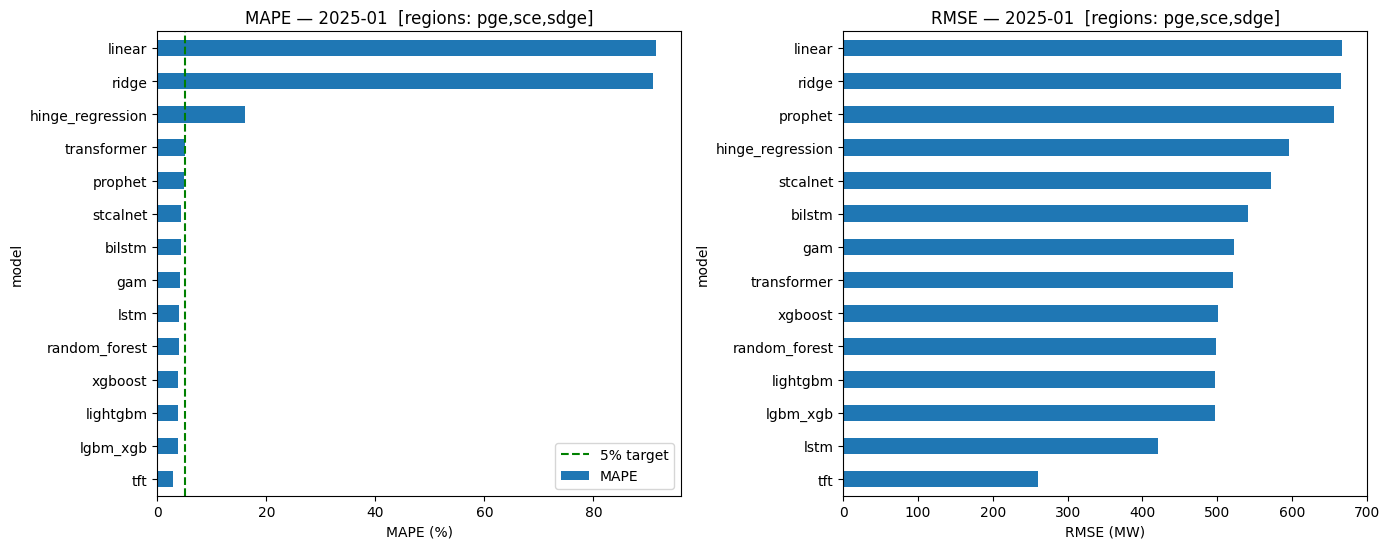

Saved plot: outputs/model_runs/plots/comparison_2025-01.png


In [19]:
import glob, os
import pandas as pd
import matplotlib.pyplot as plt

PLOTS_DIR = f'{OUTPUT_DIR}/plots'
os.makedirs(PLOTS_DIR, exist_ok=True)

metrics_files = sorted(glob.glob(f'{OUTPUT_DIR}/*_{PREDICT_MONTH}_metrics.csv'))
if not metrics_files:
    print('No metrics files found yet. Run some model cells first.')
else:
    rows = []
    for fp in metrics_files:
        mname = os.path.basename(fp).replace(f'_{PREDICT_MONTH}_metrics.csv', '')
        m = pd.read_csv(fp)
        row = {'model': mname}
        row.update(m.iloc[0].to_dict() if len(m) == 1 else m.mean(numeric_only=True).to_dict())
        rows.append(row)

    summary = pd.DataFrame(rows).set_index('model')
    cols = [c for c in ['MAPE', 'RMSE', 'MAE'] if c in summary.columns]
    if 'MAPE' in summary.columns:
        summary = summary.sort_values('MAPE')
    print(f'Results for {PREDICT_MONTH}  [regions: {REGIONS}]\n')
    display(summary[cols].round(3) if cols else summary.round(3))

    # Save summary table to CSV
    summary_csv = f'{PLOTS_DIR}/summary_{PREDICT_MONTH}.csv'
    summary.to_csv(summary_csv)
    print(f'Saved summary table: {summary_csv}')

    if 'MAPE' in summary.columns:
        fig, axes = plt.subplots(1, 2, figsize=(14, max(3, len(summary) * 0.4)))

        summary['MAPE'].plot(kind='barh', ax=axes[0])
        axes[0].set_xlabel('MAPE (%)')
        axes[0].set_title(f'MAPE — {PREDICT_MONTH}  [regions: {REGIONS}]')
        axes[0].axvline(x=5, color='green', linestyle='--', label='5% target')
        axes[0].legend()

        if 'RMSE' in summary.columns:
            summary['RMSE'].sort_values().plot(kind='barh', ax=axes[1])
            axes[1].set_xlabel('RMSE (MW)')
            axes[1].set_title(f'RMSE — {PREDICT_MONTH}  [regions: {REGIONS}]')

        plt.tight_layout()
        plot_path = f'{PLOTS_DIR}/comparison_{PREDICT_MONTH}.png'
        plt.savefig(plot_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'Saved plot: {plot_path}')

## 5. Prediction plot
Set `PLOT_MODEL` to whichever model you want to inspect.

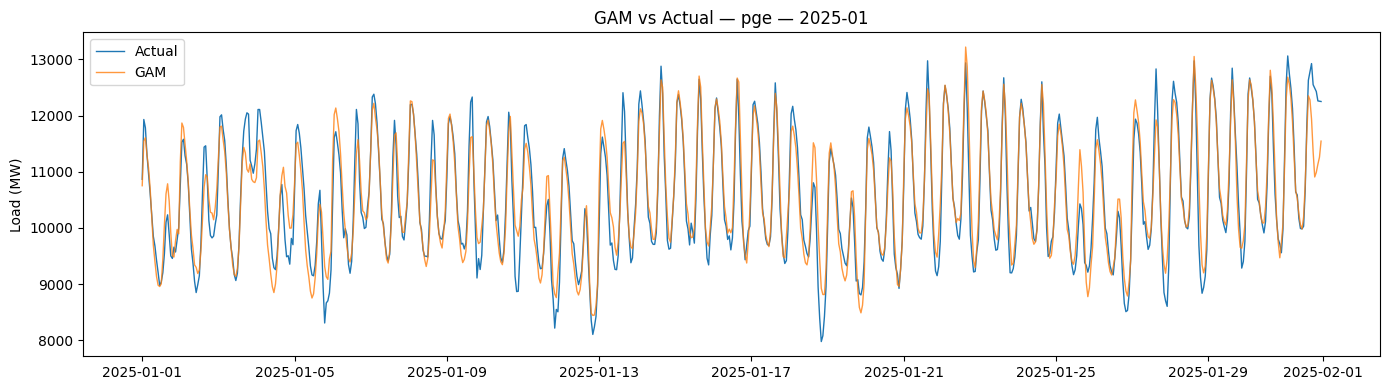

In [20]:
PLOT_MODEL  = 'gam'
PLOT_REGION = None  # None = first region found

pred_file = f'{OUTPUT_DIR}/{PLOT_MODEL}_{PREDICT_MONTH}_predictions.csv'
if not os.path.exists(pred_file):
    print(f'No predictions file for {PLOT_MODEL}. Run that model cell first.')
else:
    preds = pd.read_csv(pred_file)

    if 'time_utc' in preds.columns:
        preds['time_utc'] = pd.to_datetime(preds['time_utc'])

    actual_col = 'actual_load_mw' if 'actual_load_mw' in preds.columns else 'actual'
    pred_col = 'predicted_load_mw' if 'predicted_load_mw' in preds.columns else 'predicted'

    regions = preds['region'].unique() if 'region' in preds.columns else [None]
    region  = PLOT_REGION or regions[0]
    grp     = preds[preds['region'] == region] if region else preds
    x_col   = 'time_utc' if 'time_utc' in grp.columns else grp.index

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(grp[x_col].values, grp[actual_col].values, label='Actual', lw=1)
    ax.plot(grp[x_col].values, grp[pred_col].values, label=PLOT_MODEL.upper(), lw=1, alpha=0.8)
    ax.set_title(f'{PLOT_MODEL.upper()} vs Actual — {region} — {PREDICT_MONTH}')
    ax.set_ylabel('Load (MW)')
    ax.legend()
    plt.tight_layout()
    plt.show()


## 6. Run all models in one shot
Uncomment all lines and run — equivalent to `scripts/train_forecasters.sh`.  
Expected time on T4 GPU: **40–60 min** for all 13 models.

In [21]:
# run_model('linear')
# run_model('ridge',           '--ridge_alpha 10.0')
# run_model('hinge_regression','--svr_c 1.0 --svr_epsilon 0.1 --svr_max_iter 5000')
# run_model('xgboost')
# run_model('random_forest',   '--rf_n_estimators 300')
# run_model('lightgbm',        '--lgbm_n_estimators 300 --lgbm_learning_rate 0.05 --lgbm_num_leaves 31')
# run_model('lgbm_xgb',        '--lgbm_n_estimators 300 --lgbm_learning_rate 0.05 --lgbm_num_leaves 31 --xgb_n_estimators 300 --xgb_learning_rate 0.05 --ensemble_weight 0.5')
# run_model('gam',             '--gam_n_splines 25 --gam_lam 0.6')
# run_model('prophet',         '--prophet_changepoint_prior_scale 0.05 --prophet_seasonality_prior_scale 10.0')
# run_model('lstm',            '--lookback 24 --epochs 10 --batch_size 128 --lr 0.001 --hidden_dim 64 --num_layers 2 --dropout 0.1')
# run_model('bilstm',          '--lookback 24 --epochs 10 --batch_size 128 --lr 0.001 --hidden_dim 64 --num_layers 2 --dropout 0.1')
# run_model('transformer',     '--lookback 24 --epochs 10 --batch_size 128 --lr 0.001 --d_model 64 --nhead 4 --num_layers 2 --dim_feedforward 128 --dropout 0.1')
# run_model('stcalnet',        '--lookback 24 --epochs 10 --batch_size 128 --lr 0.001 --hidden_dim 64 --num_layers 2 --cnn_channels 64 --dropout 0.1')
print('Uncomment lines above to run everything at once.')

Uncomment lines above to run everything at once.


## 7. Full 2025 sweep — all models × all 12 months\nEquivalent to running `scripts/train_forecasters.sh` for the full year.\nExpected runtime on T4 GPU: **8–12 hours** for all models × 12 months.\nRun the summary cell afterwards to get the full heatmap.

In [7]:
MONTHS_2025 = [f'2025-{m:02d}' for m in range(1, 13)]

MODELS_2025 = [
    ('linear',           ''),
    ('ridge',            '--ridge_alpha 10.0'),
    ('hinge_regression', '--svr_c 1.0 --svr_epsilon 0.1 --svr_max_iter 5000'),
    ('xgboost',          ''),
    ('random_forest',    '--rf_n_estimators 300'),
    ('lightgbm',         '--lgbm_n_estimators 300 --lgbm_learning_rate 0.05 --lgbm_num_leaves 31'),
    ('lgbm_xgb',         '--lgbm_n_estimators 300 --lgbm_learning_rate 0.05 --lgbm_num_leaves 31 --xgb_n_estimators 300 --xgb_learning_rate 0.05 --ensemble_weight 0.5'),
    ('gam',              '--gam_n_splines 25 --gam_lam 0.6'),
    ('prophet',          '--prophet_changepoint_prior_scale 0.05 --prophet_seasonality_prior_scale 10.0'),
    ('lstm',             '--lookback 24 --epochs 10 --batch_size 128 --lr 0.001 --hidden_dim 64 --num_layers 2 --dropout 0.1'),
    ('bilstm',           '--lookback 24 --epochs 10 --batch_size 128 --lr 0.001 --hidden_dim 64 --num_layers 2 --dropout 0.1'),
    ('transformer',      '--lookback 24 --epochs 10 --batch_size 128 --lr 0.001 --d_model 64 --nhead 4 --num_layers 2 --dim_feedforward 128 --dropout 0.1'),
    ('stcalnet',         '--lookback 24 --epochs 10 --batch_size 128 --lr 0.001 --hidden_dim 64 --num_layers 2 --cnn_channels 64 --dropout 0.1'),
]

total = len(MONTHS_2025) * len(MODELS_2025)
done  = 0
errors = []

for month in MONTHS_2025:
    # temporarily override PREDICT_MONTH for run_model
    _orig = PREDICT_MONTH
    # patch the global used by run_model
    import builtins
    PREDICT_MONTH = month  # noqa: F811

    for model_name, extra in MODELS_2025:
        # skip if already done
        out_met = f'{OUTPUT_DIR}/{model_name}_{month}_metrics.csv'
        if os.path.exists(out_met):
            print(f'[SKIP] {model_name} {month} already exists')
            done += 1
            continue
        try:
            run_model(model_name, extra)
        except Exception as e:
            print(f'[ERROR] {model_name} {month}: {e}')
            errors.append((model_name, month, str(e)))
        done += 1
        print(f'Progress: {done}/{total}')

PREDICT_MONTH = _orig  # restore
print(f'\nSweep complete. Errors: {len(errors)}')
for e in errors:
    print(f'  {e[0]} {e[1]}: {e[2]}')

[SKIP] linear 2025-01 already exists
[SKIP] ridge 2025-01 already exists
[SKIP] hinge_regression 2025-01 already exists
[SKIP] xgboost 2025-01 already exists

Running random_forest for 2025-01  [regions: pge,sce,sdge]

Forecasting pipeline: 100%|██████████| 7/7 [02:08<00:00, 18.40s/step]

[INFO] Reading CSV...

[INFO] Region filter: ['pge', 'sce', 'sdge'] (165,477 rows kept)

[INFO] Preparing train/validation split from predict_month...
[INFO] predict_month           : 2025-01
[INFO] training window end     : 2024-12-31 23:59:59
[INFO] validation window start : 2025-01-01 00:00:00
[INFO] validation window end   : 2025-01-31 23:59:59
[INFO] TRAIN: dropped 0 rows (missing load_mw=0, missing load_previous_week=0).
[INFO] VALID: dropped 0 rows (missing load_mw=0, missing load_previous_week=0).

[INFO] Building shared feature pipeline...

[INFO] Training model: random_forest

[INFO] Computing validation metrics...

VALIDATION METRICS
RMSE           : 498.0293
MAE            : 299.6258
MAPE 

In [8]:
MONTHS_2025 = [f'2025-{m:02d}' for m in range(1, 13)]

MODELS_2025 = [
    ('bilstm',           '--lookback 24 --epochs 10 --batch_size 128 --lr 0.001 --hidden_dim 64 --num_layers 2 --dropout 0.1'),
]

total = len(MONTHS_2025) * len(MODELS_2025)
done  = 0
errors = []

for month in MONTHS_2025:
    # temporarily override PREDICT_MONTH for run_model
    _orig = PREDICT_MONTH
    # patch the global used by run_model
    import builtins
    PREDICT_MONTH = month  # noqa: F811

    for model_name, extra in MODELS_2025:
        # skip if already done
        out_met = f'{OUTPUT_DIR}/{model_name}_{month}_metrics.csv'
        if os.path.exists(out_met):
            print(f'[SKIP] {model_name} {month} already exists')
            done += 1
            continue
        try:
            run_model(model_name, extra)
        except Exception as e:
            print(f'[ERROR] {model_name} {month}: {e}')
            errors.append((model_name, month, str(e)))
        done += 1
        print(f'Progress: {done}/{total}')

PREDICT_MONTH = _orig  # restore
print(f'\nSweep complete. Errors: {len(errors)}')
for e in errors:
    print(f'  {e[0]} {e[1]}: {e[2]}')

[SKIP] bilstm 2025-01 already exists
[SKIP] bilstm 2025-02 already exists
[SKIP] bilstm 2025-03 already exists
[SKIP] bilstm 2025-04 already exists
[SKIP] bilstm 2025-05 already exists
[SKIP] bilstm 2025-06 already exists
[SKIP] bilstm 2025-07 already exists
[SKIP] bilstm 2025-08 already exists
[SKIP] bilstm 2025-09 already exists
[SKIP] bilstm 2025-10 already exists
[SKIP] bilstm 2025-11 already exists
[SKIP] bilstm 2025-12 already exists

Sweep complete. Errors: 0


Annual MAPE by model and month:



month,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12,avg
model,,,,,,,,,,,,,
stcalnet,4.75,3.98,4.63,5.16,4.41,4.60,3.62,3.67,4.29,4.31,4.83,4.46,4.39
bilstm,4.29,5.14,4.40,5.41,4.40,4.79,4.18,3.57,3.92,4.65,4.79,4.54,4.51
lgbm_xgb,3.81,4.50,4.94,4.53,5.02,5.13,4.59,4.69,4.68,4.59,4.36,3.96,4.57
lightgbm,3.86,4.75,5.18,4.70,5.20,5.11,4.62,4.83,4.77,4.64,4.49,4.04,4.68
random_forest,3.92,4.85,5.35,4.86,5.30,5.76,5.13,4.86,5.44,4.93,4.42,4.25,4.92
prophet,4.97,6.41,6.70,6.50,6.12,6.47,7.18,5.36,5.76,5.83,6.03,6.61,6.16
gam,7.07,7.33,7.77,7.65,7.07,6.82,18.98,5.65,6.29,6.53,6.60,6.40,7.85
xgboost,11.25,14.70,14.35,13.58,15.64,19.80,49.75,12.68,18.81,23.55,22.33,15.41,19.32
hinge_regression,16.08,18.57,21.26,18.17,20.84,23.28,36.06,27.26,27.40,23.08,24.78,19.35,23.01


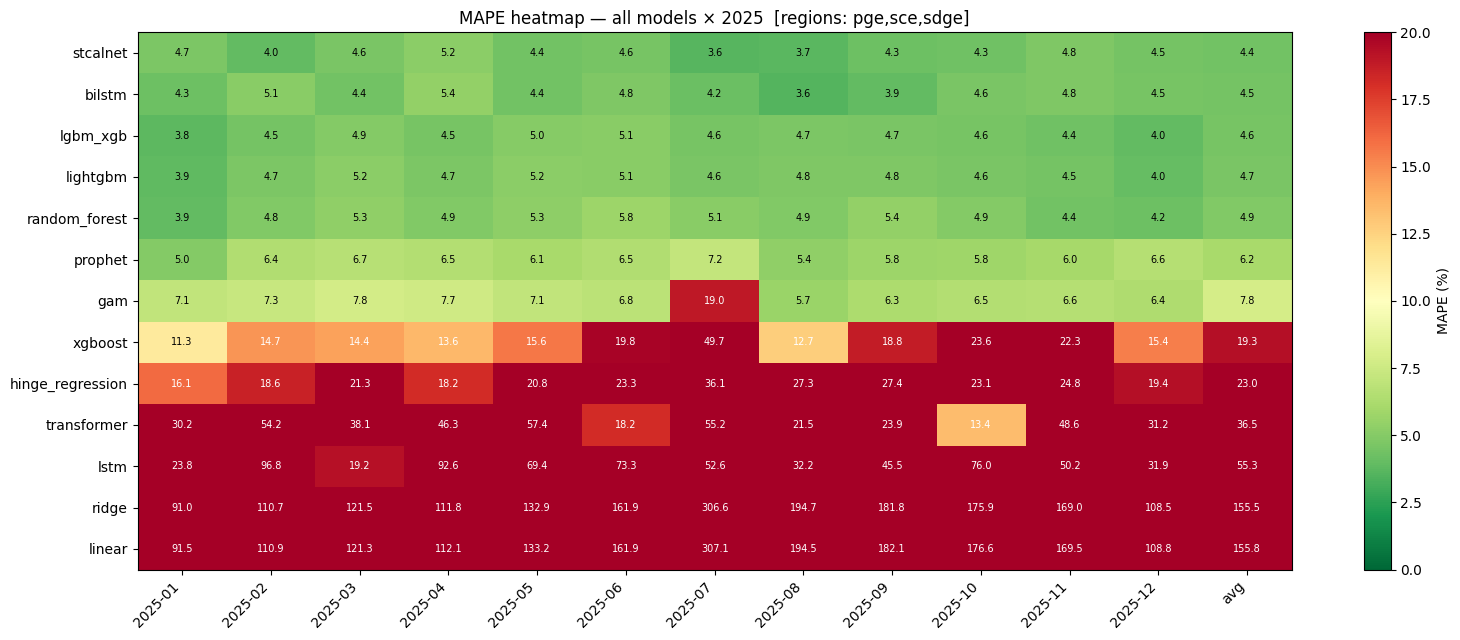

Saved: outputs/model_runs/plots/mape_heatmap_2025.png


In [9]:
# Annual summary — MAPE heatmap across all models × all months
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PLOTS_DIR = f'{OUTPUT_DIR}/plots'
os.makedirs(PLOTS_DIR, exist_ok=True)

all_files = glob.glob(f'{OUTPUT_DIR}/*_2025-*_metrics.csv')
rows = []
for fp in all_files:
    fname = os.path.basename(fp)
    for m in [f'2025-{mm:02d}' for mm in range(1, 13)]:
        if f'_{m}_metrics' in fname:
            model = fname.replace(f'_{m}_metrics.csv', '')
            df = pd.read_csv(fp)
            mape = df['MAPE'].mean() if 'MAPE' in df.columns else float('nan')
            rmse = df['RMSE'].mean() if 'RMSE' in df.columns else float('nan')
            rows.append({'model': model, 'month': m, 'MAPE': mape, 'RMSE': rmse})
            break

if not rows:
    print('No results found. Run the sweep first.')
else:
    annual = pd.DataFrame(rows)

    mape_pivot = annual.pivot_table(index='model', columns='month', values='MAPE')
    mape_pivot['avg'] = mape_pivot.mean(axis=1)
    mape_pivot = mape_pivot.sort_values('avg')

    print('Annual MAPE by model and month:\n')
    display(mape_pivot.round(2))

    fig, ax = plt.subplots(figsize=(16, max(4, len(mape_pivot) * 0.5)))
    im = ax.imshow(mape_pivot.values, aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=20)
    ax.set_xticks(range(len(mape_pivot.columns)))
    ax.set_xticklabels(mape_pivot.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(mape_pivot.index)))
    ax.set_yticklabels(mape_pivot.index)
    for i in range(len(mape_pivot.index)):
        for j in range(len(mape_pivot.columns)):
            v = mape_pivot.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, f'{v:.1f}', ha='center', va='center', fontsize=7,
                        color='white' if v > 12 else 'black')
    plt.colorbar(im, ax=ax, label='MAPE (%)')
    ax.set_title(f'MAPE heatmap — all models × 2025  [regions: {REGIONS}]')
    plt.tight_layout()
    heatmap_path = f'{PLOTS_DIR}/mape_heatmap_2025.png'
    plt.savefig(heatmap_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {heatmap_path}')

## 8. Save outputs to Google Drive
Colab's runtime is wiped when it disconnects. Run this cell to copy all results to Drive so you don't lose them.

In [10]:
import shutil, glob, os
from google.colab import drive

drive.mount('/content/drive')

# ── Edit this if your Millenium_repo folder is somewhere else on Drive ──
DRIVE_OUT = '/content/drive/MyDrive/Millenium_repo/outputs/model_runs'
os.makedirs(DRIVE_OUT, exist_ok=True)

# Copy all CSVs (organised by month subfolder)
csv_files = glob.glob(f'{OUTPUT_DIR}/*_metrics.csv') + glob.glob(f'{OUTPUT_DIR}/*_predictions.csv')
for f in csv_files:
    fname = os.path.basename(f)
    month = next((f'2025-{mm:02d}' for mm in range(1, 13) if f'2025-{mm:02d}' in fname), 'misc')
    dest_dir = os.path.join(DRIVE_OUT, month)
    os.makedirs(dest_dir, exist_ok=True)
    shutil.copy(f, os.path.join(dest_dir, fname))

# Copy plots
plot_files = glob.glob(f'{OUTPUT_DIR}/plots/*.png') + glob.glob(f'{OUTPUT_DIR}/plots/*.csv')
plots_drive = os.path.join(DRIVE_OUT, 'plots')
os.makedirs(plots_drive, exist_ok=True)
for f in plot_files:
    shutil.copy(f, os.path.join(plots_drive, os.path.basename(f)))

print(f'Copied {len(csv_files)} CSVs + {len(plot_files)} plots to:')
print(f'  {DRIVE_OUT}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copied 313 CSVs + 1 plots to:
  /content/drive/MyDrive/Millenium_repo/outputs/model_runs


#Copy Everything Over to main repo


In [11]:
import shutil, os
from google.colab import drive

drive.mount('/content/drive')

src = '/content/Load-Forecasting/outputs/model_runs'
dst = '/content/drive/MyDrive/Millenium_repo/outputs/model_runs'

shutil.copytree(src, dst, dirs_exist_ok=True)
print('Done.')
dirs_exist_ok=True

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Done.
